In [1]:
import pandas as pd
import os
import numpy as np
import json 

annotated_comments_dir = 'VideosComments/youtube/annotated_comments/{newspaper}'
annotated_metadata_dir = 'VideosComments/youtube/annotated_metadata/{newspaper}'

newspapers = ["corriere_della_sera", "repubblica", "lastampa", "ilmessaggero", "il_gazzettino"]

all_comments_gold = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _gold at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_gold.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_gold.json'))
    matching_ids = set(f.split('_gold')[0] for f in comment_files) & set(f.split('_gold')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_gold.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_gold.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_gold.append(comments_df)

all_comments_silver = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _silver at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_silver.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_silver.json'))
    matching_ids = set(f.split('_silver')[0] for f in comment_files) & set(f.split('_silver')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_silver.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_silver.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_silver.append(comments_df)

,comment_id,parent_comment_id,video_id,is_reply,author,published_at,updated_at,like_count,text,inferred_parent_id,depth,newspaper,author_anon,label,topic
0,UgzZI8TfZlE8AnWQ6MJ4AaABAg,NaN,RlKqohuIcfc,False,@brunellabrianzi6452,2026-05-19T12:45:17Z,2026-05-19T12:45:17Z,0,"Sembra che abbiano azzardato troppo, sarebbe ...",NaN,0.0,corriere_della_sera,author_4060,0,"disaster, accident and emergency incident"
1,UgxMnhx9K35CIa_L5Wd4AaABAg,NaN,RIdMlHkZj2o,False,@SIMPLYDAW,2026-05-18T16:55:16Z,2026-05-18T16:55:16Z,10,"Basta con queste giustificazioni , troppo spes...",NaN,0.0,corriere_della_sera,author_4138,1,politics and government
2,Ugx_MOb3bumKDGAAZGR4AaABAg,NaN,RIdMlHkZj2o,False,@sergiopetruzzi101,2026-05-18T17:14:25Z,2026-05-18T17:14:25Z,7,"Anche piandedosi si e' bevuto il cervello ,gio...",NaN,0.0,corriere_della_sera,author_723,1,politics and government
3,UgzLKfdilW-tEjltPaB4AaABAg,NaN,RIdMlHkZj2o,False,@massimilianomonino9567,2026-05-18T17:47:03Z,2026-05-18T17:47:03Z,5,Maledetti politici... passerà per disagiato e ...,NaN,0.0,corriere_della_sera,author_4139,1,politics and government
4,UgzLKfdilW-tEjltPaB4AaABAg.AWxnSjH6egGAWxzMVYMuYL,UgzLKfdilW-tEjltPaB4AaABAg,RIdMlHkZj2o,True,@citikane59,2026-05-18T19:31:04Z,2026-05-18T19:31:04Z,0,"Bastava dargli un lavoro vicino a casa, come a...",UgzLKfdilW-tEjltPaB4AaABAg,1.0,corriere_della_sera,author_4140,0,politics and government
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13431,UgwY-aK_b7T2YXQswVt4AaABAg,NaN,pSKv_OPoWUs,False,@daryg352,2026-05-17T10:23:04Z,2026-05-17T10:23:04Z,3,Il lusso è un diritto ma non è per tutti. Solo...,NaN,0.0,il_gazzettino,author_6759,0,"crime, law and justice"
13432,UgzlqSitheaRboO1qgx4AaABAg,NaN,pSKv_OPoWUs,False,@moreno9622,2026-05-17T10:58:41Z,2026-05-17T10:58:41Z,5,Andranno da Landini a protestare 😂😂😂😂,NaN,0.0,il_gazzettino,author_709,1,"crime, law and justice"
13433,UgwZ6mFfpJbAg76Yxtp4AaABAg,NaN,pSKv_OPoWUs,False,@andreamancini-g3g,2026-05-18T17:26:46Z,2026-05-18T17:26:46Z,0,bruciate i campi room,NaN,0.0,il_gazzettino,author_120,1,"crime, law and justice"
13434,UgzllVsQ8ok1HHNyhMR4AaABAg,NaN,pSKv_OPoWUs,False,@frac8383,2026-05-19T12:30:27Z,2026-05-19T12:30:27Z,0,Strano,NaN,0.0,il_gazzettino,author_2864,0,"crime, law and justice"


In [2]:
all_comments_gold_df = pd.concat(all_comments_gold, ignore_index=True)
print(f"Length of all comments: {len(all_comments_gold_df)}")

all_comments_silver_df = pd.concat(all_comments_silver, ignore_index=True)
print(f"Length of all comments: {len(all_comments_silver_df)}")

Length of all comments: 776
Length of all comments: 13436


In [4]:
sum(all_comments_gold_df['label']) / len(all_comments_gold_df)
for newspaper in newspapers:
    print(f"Percentage of offensive comments for that newspaper: {newspaper}")
    print(f"Number of comments for that newspaper: {len(all_comments_gold_df[all_comments_gold_df['newspaper'] == newspaper])}")
    newspaper_df = all_comments_gold_df[all_comments_gold_df['newspaper'] == newspaper]
    print(round(sum(newspaper_df['label']) / len(newspaper_df) * 100, 3)) 

Percentage of offensive comments for that newspaper: corriere_della_sera
Number of comments for that newspaper: 177
18.644
Percentage of offensive comments for that newspaper: repubblica
Number of comments for that newspaper: 176
35.227
Percentage of offensive comments for that newspaper: lastampa
Number of comments for that newspaper: 85
36.471
Percentage of offensive comments for that newspaper: ilmessaggero
Number of comments for that newspaper: 169
17.16
Percentage of offensive comments for that newspaper: il_gazzettino
Number of comments for that newspaper: 169
44.379


In [5]:
sum(all_comments_silver_df['label']) / len(all_comments_silver_df)
for newspaper in newspapers:
    print(f"Percentage of offensive comments for that newspaper: {newspaper}")
    print(f"Number of comments for that newspaper: {len(all_comments_silver_df[all_comments_silver_df['newspaper'] == newspaper])}")
    newspaper_df = all_comments_silver_df[all_comments_silver_df['newspaper'] == newspaper]
    print(round(sum(newspaper_df['label']) / len(newspaper_df) * 100, 3)) 

Percentage of offensive comments for that newspaper: corriere_della_sera
Number of comments for that newspaper: 1922
63.267
Percentage of offensive comments for that newspaper: repubblica
Number of comments for that newspaper: 6303
63.589
Percentage of offensive comments for that newspaper: lastampa
Number of comments for that newspaper: 947
45.301
Percentage of offensive comments for that newspaper: ilmessaggero
Number of comments for that newspaper: 3708
60.68
Percentage of offensive comments for that newspaper: il_gazzettino
Number of comments for that newspaper: 556
51.799


- - - 
Visualizations at comment level

In [6]:
all_comments_df = pd.concat(
    [all_comments_gold_df, all_comments_silver_df],
    ignore_index=True
)

def compute_stats(df):
    overall_off = df["label"].mean() * 100
    overall_n = len(df)

    topic_stats = (
        df.groupby("topic")
        .agg(
            offensive=("label", lambda x: x.mean() * 100),
            n=("label", "size")
        )
    )

    stats = pd.concat([
        pd.DataFrame(
            {"offensive": [overall_off], "n": [overall_n]},
            index=["Total"]
        ),
        topic_stats
    ])

    stats["non_offensive"] = 100 - stats["offensive"]
    return stats


total_stats = compute_stats(all_comments_df)
gold_stats = compute_stats(all_comments_gold_df)
silver_stats = compute_stats(all_comments_silver_df)

# union of all categories
topics = ["Total"] + sorted(
    (
        set(total_stats.index)
        | set(gold_stats.index)
        | set(silver_stats.index)
    ) - {"Total"}
)

total_stats = total_stats.reindex(topics)
gold_stats = gold_stats.reindex(topics)
silver_stats = silver_stats.reindex(topics)

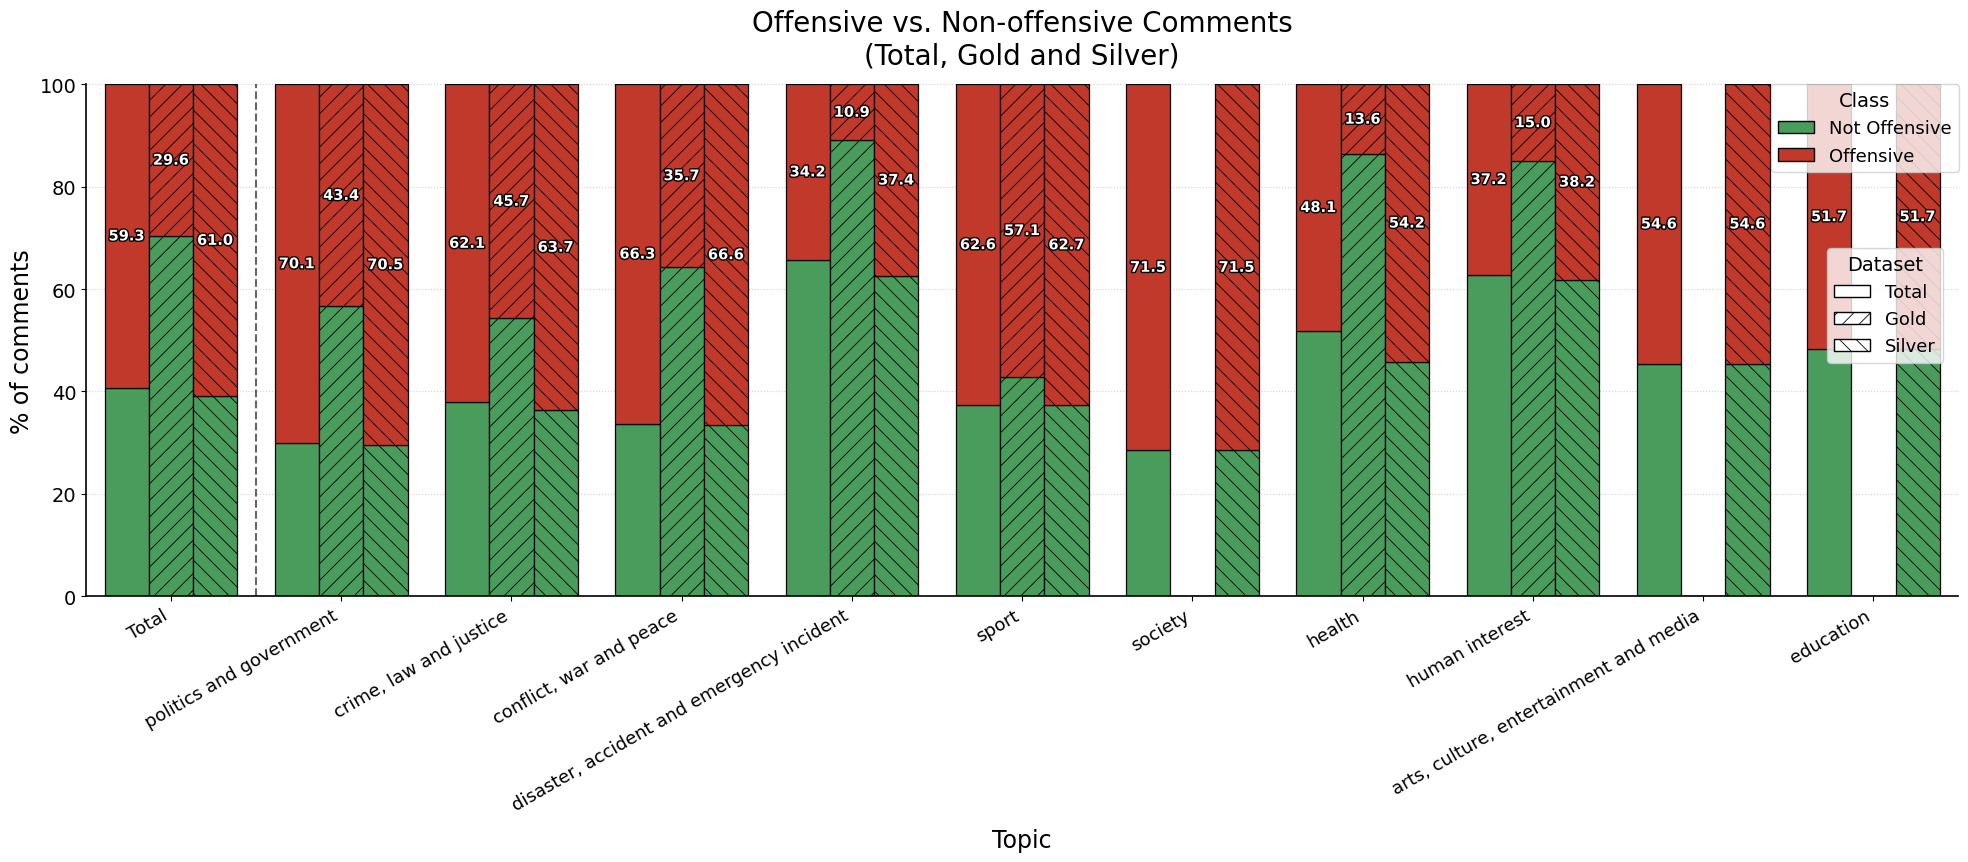

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch



# ----------------------------------------------------------------------
# Global style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size":             15,
    "axes.titlesize":        20,
    "axes.labelsize":        17,
    "xtick.labelsize":       13,
    "ytick.labelsize":       14,
    "legend.fontsize":       13,
    "legend.title_fontsize": 14,
    "axes.linewidth":        1.2,
    "hatch.linewidth":       0.6,        # <-- thinner, less noisy hatching
    "font.family":           "DejaVu Sans",
})

# Muted but clear palette (swap if you want)
COLOR_NON = "#4a9c5d"   # green  = non-offensive
COLOR_OFF = "#c0392b"   # red    = offensive

DROP_INCOMPLETE = False   # set True to hide topics missing Gold/Silver

# ----------------------------------------------------------------------
# Data prep
# ----------------------------------------------------------------------
top_topics = (
    all_comments_df["topic"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)
topics = ["Total"] + top_topics

total_plot  = total_stats.reindex(topics)
gold_plot   = gold_stats.reindex(topics)
silver_plot = silver_stats.reindex(topics)

if DROP_INCOMPLETE:
    complete = [
        t for t in topics
        if pd.notna(gold_plot.loc[t, "offensive"])
        and pd.notna(silver_plot.loc[t, "offensive"])
    ]
    topics = complete
    total_plot, gold_plot, silver_plot = (
        d.reindex(topics) for d in (total_plot, gold_plot, silver_plot)
    )

# ----------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

width = 0.26
x = np.arange(len(topics))

datasets = [
    ("Total",  total_plot,  -width),
    ("Gold",   gold_plot,    0.0),
    ("Silver", silver_plot,  width),
]
hatches = {"Total": "", "Gold": "//", "Silver": "\\\\"}

label_fx = [pe.withStroke(linewidth=2.0, foreground="black")]

for name, stats, offset in datasets:
    non_off = stats["non_offensive"].fillna(0)
    off     = stats["offensive"].fillna(0)

    ax.bar(x + offset, non_off, width=width,
           color=COLOR_NON, edgecolor="black", linewidth=0.9,
           hatch=hatches[name])
    ax.bar(x + offset, off, width=width, bottom=non_off,
           color=COLOR_OFF, edgecolor="black", linewidth=0.9,
           hatch=hatches[name])

    # Offensive % label, centered in the red segment (skip tiny segments)
    for i, val in enumerate(stats["offensive"]):
        if pd.notna(val) and val >= 4:
            ax.text(
                x[i] + offset, non_off.iloc[i] + val / 2,
                f"{val:.1f}",
                ha="center", va="center",
                color="white", fontsize=10.5, fontweight="bold",
                path_effects=label_fx,
            )

# Separator after "Total"
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, alpha=0.6)

# ----------------------------------------------------------------------
# Axes cosmetics
# ----------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(topics, rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylabel("% of comments")
ax.set_xlabel("Topic", labelpad=10)
ax.set_title("Offensive vs. Non-offensive Comments\n(Total, Gold and Silver)", pad=15)

ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.01)

# ----------------------------------------------------------------------
# Two legends (color = class, hatch = dataset)
# ----------------------------------------------------------------------
class_handles = [
    Patch(facecolor=COLOR_NON, edgecolor="black", label="Not Offensive"),
    Patch(facecolor=COLOR_OFF, edgecolor="black", label="Offensive"),
]
dataset_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=hatches[n], label=n)
    for n in ("Total", "Gold", "Silver")
]

leg1 = ax.legend(handles=class_handles, title="Class",
                 loc="upper left", bbox_to_anchor=(0.90, 1.00),
                 frameon=True, borderaxespad=0.0)
ax.add_artist(leg1)
ax.legend(handles=dataset_handles, title="Dataset",
          loc="upper left", bbox_to_anchor=(0.93, 0.68),
          frameon=True, borderaxespad=0.0)

# Reserve margins manually (DON'T use tight_layout with outside legends)
# fig.subplots_adjust(left=0.06, right=0.83, top=0.90, bottom=0.26)
fig.subplots_adjust(left=0.06, right=1.1, top=0.90, bottom=0.26)

fig.savefig("offensive_by_topic.pdf", bbox_inches="tight")          # vector, for LaTeX
fig.savefig("offensive_by_topic.png", bbox_inches="tight", dpi=300) # raster fallback
plt.show()

### Visualizations at the video level

In [3]:
import pandas as pd
df_video = pd.read_csv("video_dataset.csv")

In [4]:
df_video

,video_id,newspaper,video_text,video_description,video_topic,num_comments,num_offensive_comments,offensive_score,offensive_trigger,type
0,-Jz16gcNDG4,corriere_della_sera,"Monza, lascia in eredità 570mila euro (e una c...",La signora era deceduta nel 2019 a 93 anni nel...,human interest,20,3,0.5701,0,gold
1,-vjNeffdABU,corriere_della_sera,Genova-Milano in treno in 55 minuti dal 2030: ...,Nuovo passo avanti per il Terzo Valico dei Gio...,science and technology,2,1,0.2952,0,silver
2,019ku18Adko,corriere_della_sera,"Addio a Renato Romagnoli, il partigiano “Itali...","Finché ha potuto, Renato “Italiano” Romagnoli ...",society,4,2,0.5559,0,silver
3,06P2sBlAqf8,corriere_della_sera,"Abbiamo provato Gemini Omni, nuovo modello Goo...","Google ha appena lanciato Gemini Omni, il suo ...",science and technology,1,1,0.5000,0,silver
4,0XkW6iFCmuw,corriere_della_sera,Il sindaco di Modena: “L’uomo è stato fermato ...,«Le indagini sono in corso da parte della Proc...,"crime, law and justice",65,48,0.8640,1,silver
...,...,...,...,...,...,...,...,...,...,...
495,yxhSFzAMWCY,repubblica,A Napoli un padre accoltella il figlio dodicen...,"Un litigio improvviso in casa, poi il dramma f...","crime, law and justice",24,12,0.7942,1,silver
496,yyooDzr0s8I,repubblica,"Grossman: ""Ben-Gvir una disgrazia nazionale, n...","""Gente come Ben-Gvir, quello che lui aizza non...",politics and government,196,132,0.8866,1,silver
497,zO2XylesnrE,repubblica,"Meloni: ""Vogliamo proseguire sulla strada per ...","""La principale enorme fragilità che ci riguard...",politics and government,120,61,0.8643,1,silver
498,zSDdaX_apcQ,repubblica,"Le 50 spiagge più belle del mondo: Filippine, ...","Calette nascoste da alte scogliere, lunghe lin...",lifestyle and leisure,7,1,0.0903,0,silver


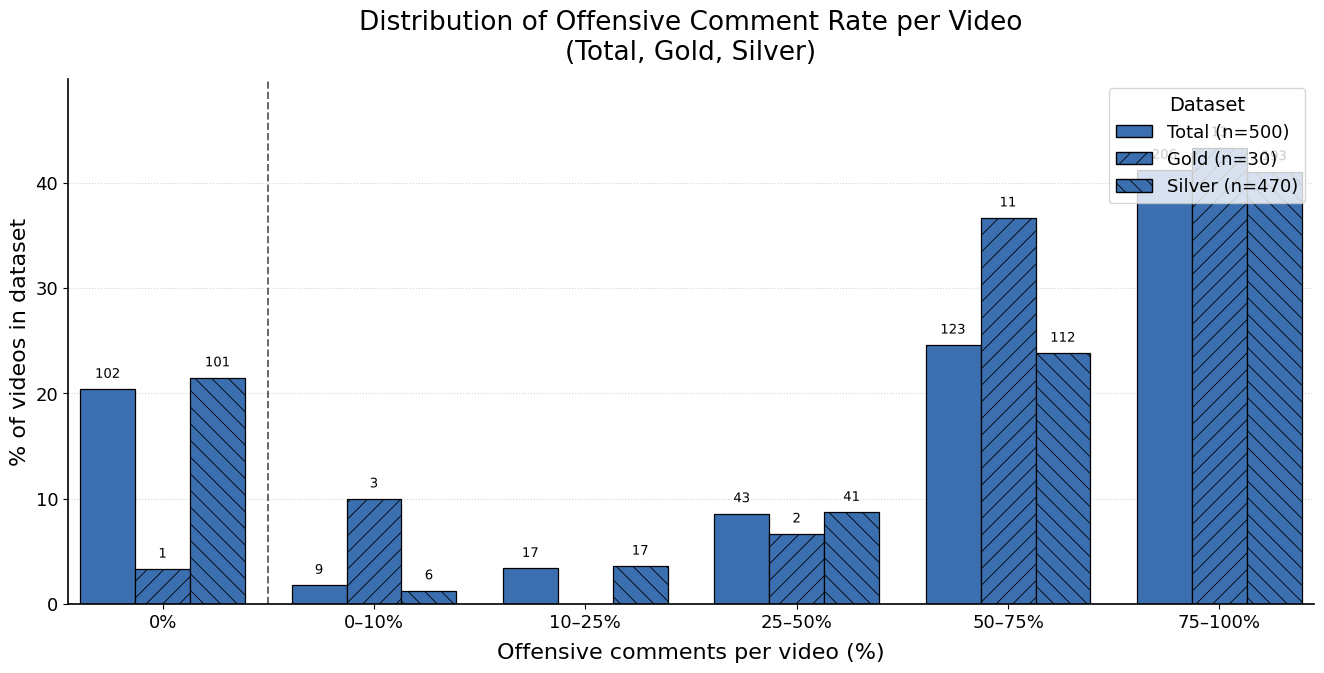

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

# ----------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size":             14,
    "axes.titlesize":        19,
    "axes.labelsize":        16,
    "xtick.labelsize":       13,
    "ytick.labelsize":       13,
    "legend.fontsize":       13,
    "legend.title_fontsize": 14,
    "axes.linewidth":        1.2,
    "hatch.linewidth":       0.6,
    "font.family":           "DejaVu Sans",
})

COLOR = "#3b6fb0"

# ----------------------------------------------------------------------
# Distribution helper
# ----------------------------------------------------------------------
def get_video_distribution(df):
    # convert offensive_score (0-1) to percentage
    off_rate = df["offensive_score"] * 100

    counts = {"0%": int((off_rate == 0).sum())}

    positive = off_rate[off_rate > 0]

    bins = [
        ("0–10%",   0.0001, 10),
        ("10–25%",  10, 25),
        ("25–50%",  25, 50),
        ("50–75%",  50, 75),
        ("75–100%", 75, 100),
    ]

    for label, low, high in bins:
        counts[label] = int(((positive > low) & (positive <= high)).sum())

    return pd.Series(counts)

# ----------------------------------------------------------------------
# Split datasets
# ----------------------------------------------------------------------
gold_df = df_video[df_video["type"].str.lower() == "gold"]
silver_df = df_video[df_video["type"].str.lower() == "silver"]

dists = {
    "Total": get_video_distribution(df_video),
    "Gold": get_video_distribution(gold_df),
    "Silver": get_video_distribution(silver_df),
}

totals = {name: d.sum() for name, d in dists.items()}
pct = {name: d / totals[name] * 100 for name, d in dists.items()}

# ----------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

bins = list(dists["Total"].index)
x = np.arange(len(bins))

width = 0.26
hatches = {"Total": "", "Gold": "//", "Silver": "\\\\"}
offsets = {"Total": -width, "Gold": 0.0, "Silver": width}

label_fx = [pe.withStroke(linewidth=1.8, foreground="white")]

for name in ("Total", "Gold", "Silver"):
    bars = ax.bar(
        x + offsets[name],
        pct[name].values,
        width=width,
        color=COLOR,
        edgecolor="black",
        linewidth=0.9,
        hatch=hatches[name],
    )

    # annotate with raw counts
    for rect, raw in zip(bars, dists[name].values):
        if rect.get_height() > 0:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_height() + 0.8,
                f"{raw}",
                ha="center",
                va="bottom",
                fontsize=9.5,
                path_effects=label_fx,
            )

# separator after 0%
ax.axvline(x=0.5, linestyle="--", color="black",
           linewidth=1.4, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(bins)

ax.set_xlabel("Offensive comments per video (%)", labelpad=8)
ax.set_ylabel("% of videos in dataset")
ax.set_title(
    "Distribution of Offensive Comment Rate per Video\n(Total, Gold, Silver)",
    pad=14
)

ax.set_ylim(0, max(max(p.values) for p in pct.values()) * 1.15)

ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.01)

dataset_handles = [
    Patch(
        facecolor=COLOR,
        edgecolor="black",
        hatch=hatches[n],
        label=f"{n} (n={totals[n]})"
    )
    for n in ("Total", "Gold", "Silver")
]

ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper right",
    frameon=True
)

fig.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.88,
    bottom=0.13
)

fig.savefig("video_offrate_dist.pdf", bbox_inches="tight")
fig.savefig("video_offrate_dist.png", bbox_inches="tight", dpi=300)

plt.show()

- - - 
### Visualizations of the metric
Careful cause entries w.o. comments are not visualized here.

In [7]:
df_video

,video_id,newspaper,video_text,video_description,video_topic,num_comments,num_offensive_comments,offensive_score,offensive_trigger,type
0,-Jz16gcNDG4,corriere_della_sera,"Monza, lascia in eredità 570mila euro (e una c...",La signora era deceduta nel 2019 a 93 anni nel...,human interest,20,3,0.5701,0,gold
1,-vjNeffdABU,corriere_della_sera,Genova-Milano in treno in 55 minuti dal 2030: ...,Nuovo passo avanti per il Terzo Valico dei Gio...,science and technology,2,1,0.2952,0,silver
2,019ku18Adko,corriere_della_sera,"Addio a Renato Romagnoli, il partigiano “Itali...","Finché ha potuto, Renato “Italiano” Romagnoli ...",society,4,2,0.5559,0,silver
3,06P2sBlAqf8,corriere_della_sera,"Abbiamo provato Gemini Omni, nuovo modello Goo...","Google ha appena lanciato Gemini Omni, il suo ...",science and technology,1,1,0.5000,0,silver
4,0XkW6iFCmuw,corriere_della_sera,Il sindaco di Modena: “L’uomo è stato fermato ...,«Le indagini sono in corso da parte della Proc...,"crime, law and justice",65,48,0.8640,1,silver
...,...,...,...,...,...,...,...,...,...,...
495,yxhSFzAMWCY,repubblica,A Napoli un padre accoltella il figlio dodicen...,"Un litigio improvviso in casa, poi il dramma f...","crime, law and justice",24,12,0.7942,1,silver
496,yyooDzr0s8I,repubblica,"Grossman: ""Ben-Gvir una disgrazia nazionale, n...","""Gente come Ben-Gvir, quello che lui aizza non...",politics and government,196,132,0.8866,1,silver
497,zO2XylesnrE,repubblica,"Meloni: ""Vogliamo proseguire sulla strada per ...","""La principale enorme fragilità che ci riguard...",politics and government,120,61,0.8643,1,silver
498,zSDdaX_apcQ,repubblica,"Le 50 spiagge più belle del mondo: Filippine, ...","Calette nascoste da alte scogliere, lunghe lin...",lifestyle and leisure,7,1,0.0903,0,silver


In [12]:
df_video[df_video["num_offensive_comments"] == 0]['num_offensive_comments']

5      0
10     0
11     0
15     0
36     0
      ..
393    0
395    0
445    0
467    0
475    0
Name: num_offensive_comments, Length: 102, dtype: int64

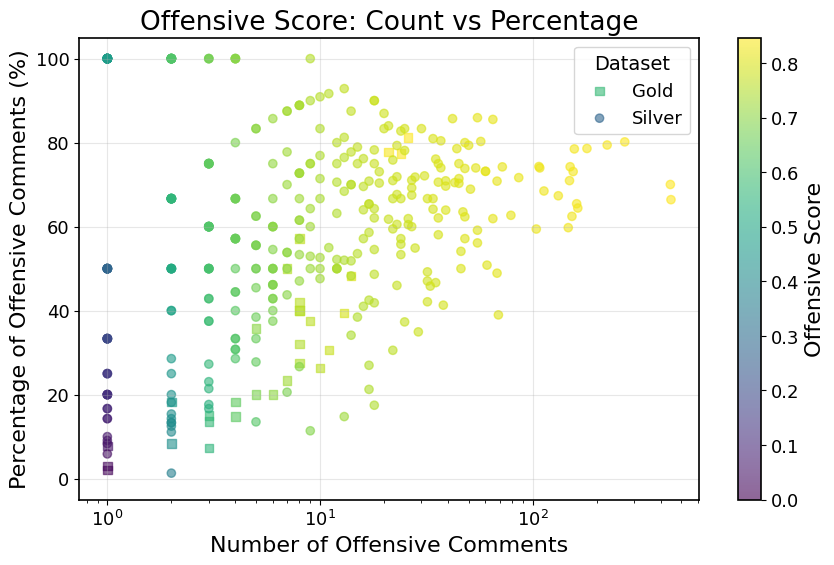

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Copy and compute percentage
# ------------------------------------------------------------------
plot_df = df_video.copy()

plot_df["offensive_pct"] = (
    plot_df["num_offensive_comments"] /
    plot_df["num_comments"].replace(0, np.nan)
) * 100

plt.figure(figsize=(10, 6))

# Gold = square
gold = plot_df[plot_df["type"].str.lower() == "gold"]

sc_gold = plt.scatter(
    gold["num_offensive_comments"],
    gold["offensive_pct"],
    c=gold["offensive_score"],
    cmap="viridis",
    alpha=0.6,
    marker="s",
    label="Gold"
)

# Silver = circle
silver = plot_df[plot_df["type"].str.lower() == "silver"]

sc_silver = plt.scatter(
    silver["num_offensive_comments"],
    silver["offensive_pct"],
    c=silver["offensive_score"],
    cmap="viridis",
    alpha=0.6,
    marker="o",
    label="Silver"
)

# Log x-axis
plt.xscale("log")

plt.xlabel("Number of Offensive Comments")
plt.ylabel("Percentage of Offensive Comments (%)")
plt.title("Offensive Score: Count vs Percentage")

# Shared colorbar
plt.colorbar(sc_gold, label="Offensive Score")

plt.legend(title="Dataset")
plt.grid(True, alpha=0.3)

plt.savefig(
    "offensive_score.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()